In [1]:
from pathlib import Path
from IPython.display import HTML, display
css = Path("../../../css/custom.css").read_text(encoding="utf-8")
display(HTML(f"<style>{css}</style>"))

# Chapter 8 — Instance-Based Learning
## Lesson 5: Applications and Challenges

In [2]:
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, balanced_accuracy_score, classification_report, f1_score
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_STATE = 42
sns.set_theme(style="whitegrid", context="notebook")

K-Nearest Neighbors is appealing because it can adapt to local patterns with little model-building ceremony. It is used in recommendation-like retrieval, image and text similarity, anomaly detection, geographic classification, medical decision support, customer segmentation, and as a practical baseline for many tabular problems. But a method that works beautifully in a notebook can also fail quietly when distance does not match the domain, data are sparse or biased, classes are imbalanced, or prediction latency becomes unacceptable.

This lesson treats KNN as an applied system rather than only an algorithm. We will build a geographic restaurant-brand example from Fast_Food_Restaurants_US.csv, inspect real data-quality issues, select K with validation, inspect local neighbors, and measure how prediction time changes with training-set size. We then use diabetes.csv as a healthcare-style classification example to show why balanced metrics and responsible interpretation matter.

The goal is not to claim that KNN can identify restaurants or diagnose patients in production. The goal is to learn the questions that must be answered before a distance-based model is trusted.

In [3]:
fast_food_path = Path("../../../Datasets/Classification/Fast_Food_Restaurants_US.csv")
fast_food = pd.read_csv(fast_food_path)

display(fast_food.head())
display(fast_food.dtypes.rename("dtype").to_frame())
quality_summary = pd.DataFrame({
    "rows": [len(fast_food)],
    "duplicate_rows": [fast_food.duplicated().sum()],
    "missing_latitude": [fast_food["latitude"].isna().sum()],
    "missing_longitude": [fast_food["longitude"].isna().sum()],
    "unique_restaurant_names": [fast_food["name"].nunique()],
})
display(quality_summary)

,Unnamed: 0,address,categories,city,country,latitude,longitude,name,postalCode,province,websites
0,0,800 N Canal Blvd,American Restaurant and Fast Food Restaurant,Thibodaux,US,29.814697,-90.814742,SONIC Drive In,70301,LA,https://locations.sonicdrivein.com/la/thibodau...
1,1,800 N Canal Blvd,Fast Food Restaurants,Thibodaux,US,29.814697,-90.814742,SONIC Drive In,70301,LA,https://locations.sonicdrivein.com/la/thibodau...
2,2,206 Wears Valley Rd,Fast Food Restaurant,Pigeon Forge,US,35.803788,-83.580553,Taco Bell,37863,TN,"http://www.tacobell.com,https://locations.taco..."
3,3,3652 Parkway,Fast Food,Pigeon Forge,US,35.782339,-83.551408,Arby's,37863,TN,"http://www.arbys.com,https://locations.arbys.c..."
4,4,2118 Mt Zion Parkway,Fast Food Restaurant,Morrow,US,33.562738,-84.321143,Steak 'n Shake,30260,GA,http://www.steaknshake.com/locations/23851-ste...


,dtype
Unnamed: 0,int64
address,object
categories,object
city,object
country,object
latitude,float64
longitude,float64
name,object
postalCode,object
province,object


,rows,duplicate_rows,missing_latitude,missing_longitude,unique_restaurant_names
0,10000,0,0,0,571


### Learning goals

By the end of this lesson, you should be able to:

1. Name several useful application patterns for KNN and identify when local similarity is meaningful.
2. Turn an imperfect real dataset into a small, testable KNN application.
3. Inspect missing values, duplicates, category cardinality, and class balance before modeling.
4. Use pipelines and cross-validation to select K without test leakage.
5. Interpret local neighbors as a model explanation rather than as causal evidence.
6. Measure the prediction-time challenge of instance-based methods.
7. Compare ordinary accuracy with balanced accuracy and macro F1.
8. Recognize privacy, fairness, drift, and representation risks in similarity-based applications.

The practical question is not merely can a model predict. It is whether its similarity rule, data, performance metric, and operating conditions support a useful and responsible decision.

,selected_brand
0,McDonald's
1,Taco Bell


,count
name,
Taco Bell,600
McDonald's,600


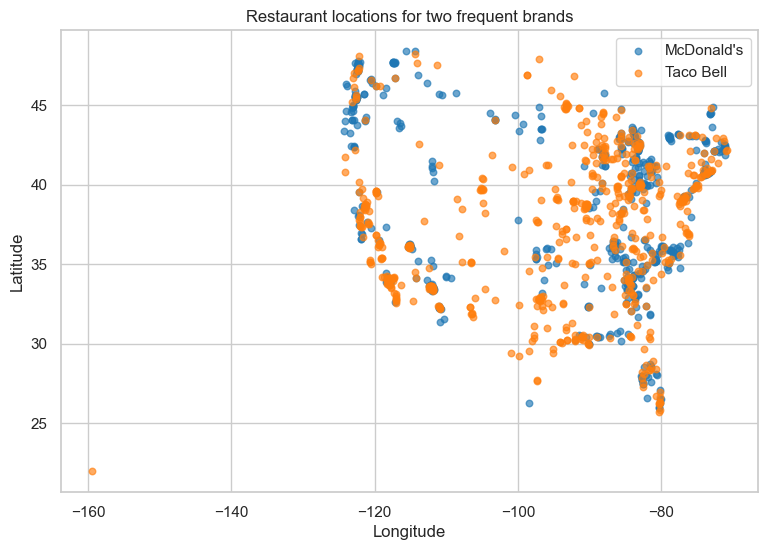

In [4]:
location_ready = fast_food.dropna(subset=["name", "latitude", "longitude", "province"]).copy()
top_brands = location_ready["name"].value_counts().head(2).index.tolist()
restaurant_data = location_ready[location_ready["name"].isin(top_brands)].drop_duplicates(subset=["name", "latitude", "longitude"]).groupby("name", group_keys=False).head(600).copy()
restaurant_X = restaurant_data[["latitude", "longitude", "province"]]
restaurant_y = restaurant_data["name"]

display(pd.DataFrame({"selected_brand": top_brands}))
display(restaurant_y.value_counts().rename("count").to_frame())

fig, ax = plt.subplots(figsize=(9, 6))
for brand, color in zip(top_brands, ["tab:blue", "tab:orange"]):
    subset = restaurant_data[restaurant_data["name"] == brand]
    ax.scatter(subset["longitude"], subset["latitude"], s=22, alpha=0.65, label=brand, color=color)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Restaurant locations for two frequent brands")
ax.legend()
plt.show()

## 1. Where KNN is useful

KNN is a natural fit when relevant examples should influence a new case directly. In image retrieval, similar feature embeddings can retrieve visually related images. In recommendation, similar users or items can suggest candidates. In fraud and anomaly workflows, a point far from its neighbors may deserve review. In geographic applications, nearby locations can share regional structure. In medicine, a patient can be compared with similar historical cases, although this requires strong safeguards and clinical validation.

The local nature of KNN is also useful for exploration. It can reveal clusters, label inconsistencies, and unusual examples without committing to a global functional form. It is often an excellent baseline because its assumptions are visible: choose a feature representation, choose a distance, choose K, and inspect neighbors.

However, the same transparency exposes challenges. Similarity is not automatically fairness, causality, or usefulness. A model may learn geographic proxies for socioeconomic variables, historical labels can contain bias, and an apparently close observation can be clinically irrelevant. KNN should support careful analysis, not replace judgment.

,k,mean_balanced_accuracy,std_balanced_accuracy
4,9,0.683,0.020
3,7,0.681,0.019
5,11,0.681,0.022
7,15,0.678,0.017
6,13,0.677,0.021
2,5,0.676,0.025
1,3,0.662,0.014
0,1,0.647,0.031


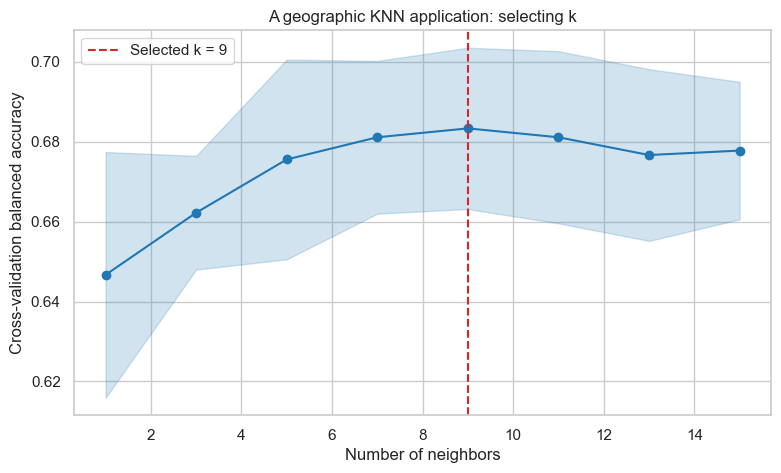

In [5]:
restaurant_X_train, restaurant_X_test, restaurant_y_train, restaurant_y_test = train_test_split(
    restaurant_X, restaurant_y, test_size=0.25, stratify=restaurant_y, random_state=RANDOM_STATE
)
geo_preprocessor = ColumnTransformer([
    ("coordinates", StandardScaler(), ["latitude", "longitude"]),
    ("province", OneHotEncoder(handle_unknown="ignore", sparse_output=False), ["province"]),
], sparse_threshold=0)
restaurant_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
k_rows = []

for k_value in range(1, 16, 2):
    candidate = make_pipeline(geo_preprocessor, KNeighborsClassifier(n_neighbors=k_value, weights="distance"))
    scores = cross_val_score(candidate, restaurant_X_train, restaurant_y_train, cv=restaurant_cv, scoring="balanced_accuracy", error_score="raise")
    k_rows.append({"k": k_value, "mean_balanced_accuracy": scores.mean(), "std_balanced_accuracy": scores.std()})

k_results = pd.DataFrame(k_rows)
selected_k = int(k_results.loc[k_results["mean_balanced_accuracy"].idxmax(), "k"])
display(k_results.sort_values("mean_balanced_accuracy", ascending=False).head(8).round(3))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(k_results["k"], k_results["mean_balanced_accuracy"], marker="o", color="tab:blue")
ax.fill_between(k_results["k"], k_results["mean_balanced_accuracy"] - k_results["std_balanced_accuracy"], k_results["mean_balanced_accuracy"] + k_results["std_balanced_accuracy"], color="tab:blue", alpha=0.2)
ax.axvline(selected_k, color="tab:red", linestyle="--", label=f"Selected k = {selected_k}")
ax.set_xlabel("Number of neighbors")
ax.set_ylabel("Cross-validation balanced accuracy")
ax.set_title("A geographic KNN application: selecting k")
ax.legend()
plt.show()

## 2. Application example: classifying restaurant brands from location

The fast-food file contains names, location fields, categories, postal information, websites, and repeated records. Its first rows and data types are inspected before we build anything. For a compact, reproducible example, we select the two most frequent restaurant names that have geographic coordinates and province information. The features are latitude, longitude, and province; the target is the restaurant name.

This is deliberately a limited demonstration. Location can help distinguish brands because chains have regional footprints, but it can also encode historical business decisions and create overly optimistic performance if duplicate locations leak between splits. We remove exact name-and-coordinate duplicates in the selected subset, use a stratified split, and keep the interpretation modest: this is a geographic similarity application, not a general restaurant-identification service.

,metric,test_value
0,accuracy,0.71
1,balanced_accuracy,0.71


,precision,recall,f1-score,support
McDonald's,0.686,0.773,0.727,150.00
Taco Bell,0.740,0.647,0.690,150.00
accuracy,0.710,0.710,0.710,0.71
macro avg,0.713,0.710,0.709,300.00
weighted avg,0.713,0.710,0.709,300.00


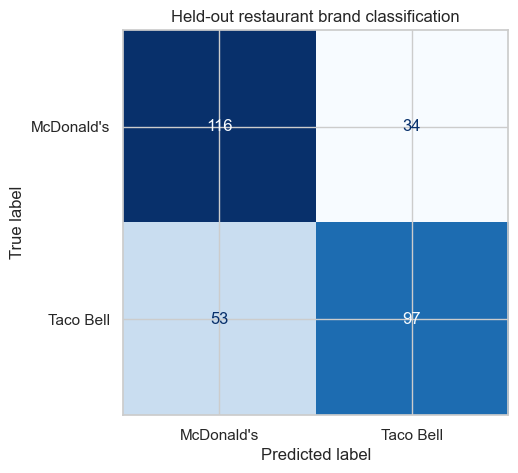

In [6]:
restaurant_model = make_pipeline(geo_preprocessor, KNeighborsClassifier(n_neighbors=selected_k, weights="distance"))
restaurant_model.fit(restaurant_X_train, restaurant_y_train)
restaurant_prediction = restaurant_model.predict(restaurant_X_test)

display(pd.DataFrame({
    "metric": ["accuracy", "balanced_accuracy"],
    "test_value": [accuracy_score(restaurant_y_test, restaurant_prediction), balanced_accuracy_score(restaurant_y_test, restaurant_prediction)],
}).round(3))
display(pd.DataFrame(classification_report(restaurant_y_test, restaurant_prediction, output_dict=True, zero_division=0)).T.round(3))

fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay.from_predictions(restaurant_y_test, restaurant_prediction, cmap="Blues", colorbar=False, ax=ax)
ax.set_title("Held-out restaurant brand classification")
plt.show()

## 3. Data quality is part of the KNN model

Distance methods are unusually sensitive to data quality because every feature participates directly in neighborhood geometry. Missing coordinates, duplicated business listings, inconsistent brand spellings, high-cardinality categories, and outdated locations can all change the nearest neighbors. A global tree or linear model can also suffer from these issues, but KNN has no learned global structure to average them away.

We inspect duplicate rows and missing geographic values before selecting a small application subset. The province column is one-hot encoded; latitude and longitude are standardized. Standardizing coordinates is a modeling decision for this example, not a complete geographic distance model. For broad geographic ranges, great-circle distance may be more appropriate. The point is to make the distance assumption explicit and testable.

In [7]:
query_row = restaurant_X_test.iloc[[0]]
query_transformed = restaurant_model.named_steps["columntransformer"].transform(query_row)
neighbor_distances, neighbor_indices = restaurant_model.named_steps["kneighborsclassifier"].kneighbors(query_transformed)
neighbor_table = restaurant_X_train.iloc[neighbor_indices[0]].copy()
neighbor_table["brand"] = restaurant_y_train.iloc[neighbor_indices[0]].to_numpy()
neighbor_table["distance"] = neighbor_distances[0]

display(query_row.assign(predicted_brand=restaurant_model.predict(query_row), actual_brand=restaurant_y_test.iloc[0]))
display(neighbor_table.sort_values("distance").round(3))

,latitude,longitude,province,predicted_brand,actual_brand
1580,38.577614,-121.549103,CA,McDonald's,Taco Bell


,latitude,longitude,province,brand,distance
585,38.581,-121.531,CA,McDonald's,0.001
584,38.597,-121.416,CA,McDonald's,0.009
4284,38.598,-121.266,CA,Taco Bell,0.018
5107,38.475,-121.448,CA,Taco Bell,0.022
595,38.677,-121.751,CA,McDonald's,0.023
1605,38.707,-121.313,CA,Taco Bell,0.030
1577,38.746,-121.226,CA,Taco Bell,0.039
2410,38.760,-121.311,CA,Taco Bell,0.040
5109,38.345,-120.771,CA,Taco Bell,0.067


## 4. Select K with validation, then evaluate once

We select K by stratified cross-validation on the training portion, using balanced accuracy. Balanced accuracy averages recall across the two selected brands, so a more common brand cannot dominate the score merely by frequency. The test set remains untouched until the selected pipeline is evaluated once.

This workflow is the same discipline used in earlier lessons, but applications make its importance clearer. If a brand appears repeatedly at the same locations or a train-test split captures regional clusters unevenly, a single test score can be misleading. Cross-validation is not magic, yet it forces the comparison to be repeated across several training-validation partitions.

,training_rows,prediction_time_ms_for_batch
0,100,8.410
1,250,7.832
2,500,8.723
3,900,6.755


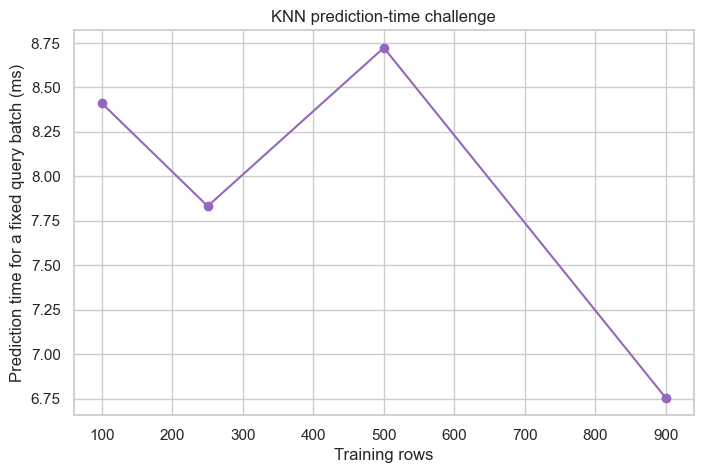

In [8]:
sample_sizes = sorted(set([min(len(restaurant_X_train), value) for value in [100, 250, 500, 1000, 2000]]))
timing_rows = []
for sample_size in sample_sizes:
    sample_X = restaurant_X_train.sample(n=sample_size, random_state=RANDOM_STATE)
    sample_y = restaurant_y_train.loc[sample_X.index]
    timing_model = make_pipeline(geo_preprocessor, KNeighborsClassifier(n_neighbors=min(selected_k, sample_size), weights="distance"))
    timing_model.fit(sample_X, sample_y)
    query_batch = restaurant_X_test.iloc[:min(100, len(restaurant_X_test))]
    start = time.perf_counter()
    timing_model.predict(query_batch)
    elapsed_ms = (time.perf_counter() - start) * 1000
    timing_rows.append({"training_rows": sample_size, "prediction_time_ms_for_batch": elapsed_ms})
timing_results = pd.DataFrame(timing_rows)
display(timing_results.round(3))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(timing_results["training_rows"], timing_results["prediction_time_ms_for_batch"], marker="o", color="tab:purple")
ax.set_xlabel("Training rows")
ax.set_ylabel("Prediction time for a fixed query batch (ms)")
ax.set_title("KNN prediction-time challenge")
plt.show()

## 5. Local explanations and their limits

The neighbor table for one query location shows the rows that influenced its prediction. It is often valuable to ask whether those neighbors make sense. Are they physically close? Do they share province? Are their labels consistent? Is one very close point dominating a distance-weighted prediction? This type of local explanation is concrete and useful for debugging.

It is not a causal explanation. Nearby restaurants do not cause a brand identity, and nearby historical patients do not cause an outcome. KNN reports an association in the stored representation. The distinction matters especially in high-stakes settings: a neighbor can be similar on recorded variables while differing on an unmeasured, important factor.

In [9]:
diabetes_path = Path("../../../Datasets/Classification/diabetes.csv")
diabetes = pd.read_csv(diabetes_path)
diabetes_X = diabetes.drop(columns="classification")
diabetes_y = diabetes["classification"]

display(diabetes.head())
display(diabetes.dtypes.rename("dtype").to_frame())
display(diabetes_y.value_counts().rename("count").to_frame())

diabetes_X_train, diabetes_X_test, diabetes_y_train, diabetes_y_test = train_test_split(
    diabetes_X, diabetes_y, test_size=0.25, stratify=diabetes_y, random_state=RANDOM_STATE
)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,classification
0,6,148,72,35,0,33.6,0.627,50,Diabetic
1,1,85,66,29,0,26.6,0.351,31,Non-Diabetic
2,8,183,64,0,0,23.3,0.672,32,Diabetic
3,1,89,66,23,94,28.1,0.167,21,Non-Diabetic
4,0,137,40,35,168,43.1,2.288,33,Diabetic


,dtype
Pregnancies,int64
Glucose,int64
BloodPressure,int64
SkinThickness,int64
Insulin,int64
BMI,float64
DiabetesPedigreeFunction,float64
Age,int64
classification,object


,count
classification,
Non-Diabetic,500
Diabetic,268


## 6. The prediction-time and memory challenge

KNN is often called a lazy learner because fitting mainly stores data. The cost appears at prediction time: a query must be compared with many stored observations, unless a specialized index or approximate-neighbor method is used. The timing experiment measures prediction time for a fixed query batch as the number of training rows grows. Exact values depend on hardware and the dataset, but the trend makes the operational challenge visible.

Memory is also a concern because training rows must be retained. In a production service, latency budgets, concurrent requests, data-refresh frequency, and privacy restrictions can make a simple KNN design unsuitable. KD-trees, Ball Trees, approximate nearest-neighbor indexes, feature compression, caching, and pre-filtering can help, but each changes the engineering trade-off.

,weights,mean_balanced_accuracy,std_balanced_accuracy
0,uniform,0.663,0.030
1,distance,0.675,0.027


,metric,test_value
0,accuracy,0.776
1,balanced_accuracy,0.728
2,macro_f1,0.738


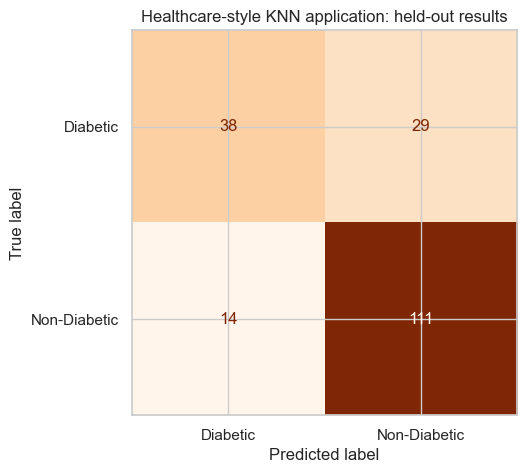

In [10]:
diabetes_rows = []
diabetes_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
for weight_rule in ["uniform", "distance"]:
    diabetes_model = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=15, weights=weight_rule))
    scores = cross_val_score(diabetes_model, diabetes_X_train, diabetes_y_train, cv=diabetes_cv, scoring="balanced_accuracy", error_score="raise")
    diabetes_rows.append({"weights": weight_rule, "mean_balanced_accuracy": scores.mean(), "std_balanced_accuracy": scores.std()})
diabetes_results = pd.DataFrame(diabetes_rows)
display(diabetes_results.round(3))

selected_weight = diabetes_results.loc[diabetes_results["mean_balanced_accuracy"].idxmax(), "weights"]
diabetes_model = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=15, weights=selected_weight))
diabetes_model.fit(diabetes_X_train, diabetes_y_train)
diabetes_prediction = diabetes_model.predict(diabetes_X_test)
display(pd.DataFrame({
    "metric": ["accuracy", "balanced_accuracy", "macro_f1"],
    "test_value": [
        accuracy_score(diabetes_y_test, diabetes_prediction),
        balanced_accuracy_score(diabetes_y_test, diabetes_prediction),
        f1_score(diabetes_y_test, diabetes_prediction, average="macro", zero_division=0),
    ],
}).round(3))

fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay.from_predictions(diabetes_y_test, diabetes_prediction, cmap="Oranges", colorbar=False, ax=ax)
ax.set_title("Healthcare-style KNN application: held-out results")
plt.show()

## 7. Healthcare-style example: metrics and caution

The diabetes dataset contains numeric health-related measurements and a binary classification label. We inspect its rows and types before fitting. This notebook uses it only as a programming example. It must not be used for medical diagnosis, and a clinical system would require external validation, calibrated probabilities, fairness analysis, medical oversight, and clear evidence that the target and features are appropriate.

For an imbalanced or cost-sensitive setting, plain accuracy is incomplete. Balanced accuracy gives equal weight to recall for each class, while macro F1 combines precision and recall across classes. The comparison of uniform and distance weights is a model-selection experiment on training folds; the held-out confusion matrix makes the pattern of mistakes visible rather than hiding it in one number.

## 8. Challenges beyond a score

Similarity-based systems face several recurring risks:

1. Representation: irrelevant, unscaled, or proxy features distort distance.
2. Sparse neighborhoods: the closest examples may still be far away.
3. Drift: new users, locations, products, or measurement processes can change neighborhood meaning.
4. Bias and fairness: historical labels and demographic proxies can make close neighbors reproduce unequal outcomes.
5. Privacy: instance-based models retain training examples, which can expose sensitive information.
6. Interpretability: neighbor lists are intuitive, but they do not establish causality.
7. Operations: memory and query-time cost grow with stored data.
8. Evaluation: random splits may overstate performance when time, groups, or locations create dependencies.

Responsible KNN practice combines technical validation with domain review. Consider time-aware, group-aware, or geographic splits when ordinary random splitting does not match deployment. Monitor data quality and performance after release. Define a fallback when no trustworthy neighbor exists.

## 9. Exercises and summary

1. Replace province with a different location-derived feature and compare the validation curve.
2. Test a group-aware split by holding out one province, then compare it to the random split.
3. Add category text features only after designing a justified text representation and distance.
4. For diabetes, change K and compare balanced accuracy, macro F1, and the confusion matrix.
5. Create an abstention rule that flags a query when its nearest-neighbor distance is above a chosen percentile.

### Summary

KNN applications work when distance captures a useful local relationship and the system can afford storing and searching examples. We built a geographic restaurant example, inspected its data quality, selected K without test leakage, interpreted local neighbors, and measured a prediction-time challenge. We also used a healthcare-style dataset to emphasize balanced evaluation and caution. Practical KNN success depends on representation, validation design, operations, ethics, and continuous monitoring as much as on the classifier call itself.